# Lab 9 — Clustering
**Group 3** | Jack Lichwa, Hemant Kumaar, Prithika K  
**Course**: DATA 5322 — Statistical Machine Learning II

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from ISLP import load_data
from sklearn.cluster import \
     (KMeans,
      AgglomerativeClustering)
from scipy.cluster.hierarchy import \
     (dendrogram,
      cut_tree)
from ISLP.cluster import compute_linkage
from sklearn.metrics import silhouette_score

---
## Part 1 

### I. Research Question

**Are there natural groups of F1 race-events based on a driver's pit stop strategy, qualifying pace relative to the field, and race completion rate?**

 Each row in the dataset is one driver in one race, so we are clustering individual race-performances. This is interesting for two reasons: it reveals whether pit stop efficiency clusters with overall race outcomes or is independently distributed across the field, and analyzes whether aggressive multi-stop strategies cluster with front-runners or out of top-3 drivers attempting to leapfrog competitors.

### II. Dataset Preparation

In [36]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/PIT-STOP-ANALYSIS'
    '/refs/heads/main/data/f1_driver_classification_data.csv'
)
df.head(3)
df.shape

(5970, 17)

In [37]:
# Explore the dataset
print("Shape:", df.shape)
print("\nColumn names and dtypes:")
print(df.dtypes)
df.head(5)

Shape: (5970, 17)

Column names and dtypes:
race_year                            int64
race_circuit                        object
race_country                        object
race_altitude_m                      int64
team                                object
race_start_position                float64
qualifying_position                float64
quali_lap_time_s                   float64
laps_completed                       int64
driver_pit_stops_count             float64
driver_pit_stops_avg_duration_s    float64
race_pit_stops_count               float64
race_pit_stops_avg_duration_s      float64
race_pit_stops_max_duration_s      float64
race_pit_stops_min_duration_s      float64
race_avg_laps_before_pit_stop      float64
top3_finish                          int64
dtype: object


,race_year,race_circuit,race_country,race_altitude_m,team,race_start_position,qualifying_position,quali_lap_time_s,laps_completed,driver_pit_stops_count,driver_pit_stops_avg_duration_s,race_pit_stops_count,race_pit_stops_avg_duration_s,race_pit_stops_max_duration_s,race_pit_stops_min_duration_s,race_avg_laps_before_pit_stop,top3_finish
0,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,1.0,1.0,85.296,58,2.0,23.319500,45.0,24.280365,37.856,16.867,23.055556,1
1,2011,Albert Park Grand Prix Circuit,Australia,10,McLaren,2.0,2.0,85.384,58,2.0,23.213000,45.0,24.280365,37.856,16.867,23.055556,1
2,2011,Albert Park Grand Prix Circuit,Australia,10,Renault,6.0,6.0,85.543,58,2.0,25.109000,45.0,24.280365,37.856,16.867,23.055556,1
3,2011,Albert Park Grand Prix Circuit,Australia,10,Ferrari,5.0,5.0,85.707,58,3.0,24.055000,45.0,24.280365,37.856,16.867,23.055556,0
4,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,3.0,3.0,85.900,58,3.0,24.058667,45.0,24.280365,37.856,16.867,23.055556,0


### III. Variables

We dropped three categories of variables: **calendar and circuit properties** (`race_year`, `race_altitude_m`) that reflect the venue rather than driver behavior; **race-level aggregates** (`race_pit_stops_count`, `race_pit_stops_avg/max/min_duration_s`, `race_avg_laps_before_pit_stop`) that are identical for every driver in the same race; and **redundant or circuit-scale-dependent variables** — `qualifying_position` is effectively the same as `race_start_position` in F1, while `quali_lap_time_s` and `laps_completed` were replaced by within-race normalized versions that remove circuit-length and circuit-speed effects.

**Features used for clustering (7 variables):**

| Feature | Type | Construction | Why included |
|---|---|---|---|
| `race_start_position` | Race context | Raw | Grid position — captures qualifying competitiveness |
| `quali_gap_to_pole_pct` | Qualifying pace | `(quali_lap_time_s − min) / min` per race | Fractional gap to pole — circuit-length-agnostic (a 1% gap means the same at Monaco and Spa) |
| `laps_pct` | Reliability | `laps_completed / max(laps_completed)` per race | Fraction of race distance completed — removes circuit-length effect |
| `driver_pit_stops_count` | Pit strategy | Raw | Number of stops chosen |
| `driver_pit_stops_avg_duration_s` | Pit execution | Raw | Absolute stop duration |
| `top3_finish` | Race outcome | Raw | Podium binary flag |
| `pit_duration_vs_race_avg` | Relative execution | `driver_avg − race_avg duration` | Seconds faster/slower than the field — removes venue and era effects |

**Preprocessing pipeline:**  
All features are standardized (zero mean, unit variance) then projected onto **principal components** retaining ≥ 85 % of variance and removes noise dimensions.

In [38]:
# ── Within-race normalization (removes circuit scale and era effects) ──
df['quali_gap_to_pole_pct'] = df.groupby(['race_year', 'race_circuit'])['quali_lap_time_s'].transform(
    lambda x: (x - x.min()) / x.min()  # % slower than pole
)
df['laps_pct'] = df.groupby(['race_year', 'race_circuit'])['laps_completed'].transform(
    lambda x: x / x.max()              # fraction of race distance
)

# ── Relative pit stop performance ──
df['pit_duration_vs_race_avg'] = (
    df['driver_pit_stops_avg_duration_s'] - df['race_pit_stops_avg_duration_s']
)

# ── Remove outliers :car failures (< 5 laps)
df_clean = df[df['laps_completed'] >= 5].copy()

# ── Drop columns 
drop_explicit = [
    'race_year', 'race_altitude_m',
    'race_pit_stops_count', 'race_pit_stops_avg_duration_s',
    'race_pit_stops_max_duration_s', 'race_pit_stops_min_duration_s',
    'race_avg_laps_before_pit_stop',
    'qualifying_position',
    'quali_lap_time_s',              
    'laps_completed',                 
]
drop_obj = [c for c in df_clean.columns if df_clean[c].dtype == object]
X_raw = df_clean.drop(columns=drop_explicit + drop_obj).dropna()

print(f"Features: {X_raw.shape[1]} variables, {X_raw.shape[0]} observations")
print(X_raw.columns.tolist())

# ── Standardize ──
scaler = StandardScaler()
X_scaled_raw = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns, index=X_raw.index)

# PCA pre-processing (builds on last week's lab)
_pca_probe = PCA(random_state=2).fit(X_scaled_raw)
_cumvar = np.cumsum(_pca_probe.explained_variance_ratio_)
n_comp = int(np.argmax(_cumvar >= 0.85)) + 1
print(f"\nPCA: {n_comp} components retain {_cumvar[n_comp-1]:.1%} of variance")

pca_fit = PCA(n_components=n_comp, random_state=2)
X_scaled = pd.DataFrame(
    pca_fit.fit_transform(X_scaled_raw),
    columns=[f'PC{i+1}' for i in range(n_comp)],
    index=X_scaled_raw.index
)
print(f"X_scaled shape: {X_scaled.shape}")
X_raw.describe().round(2)

Features: 7 variables, 5954 observations
['race_start_position', 'driver_pit_stops_count', 'driver_pit_stops_avg_duration_s', 'top3_finish', 'quali_gap_to_pole_pct', 'laps_pct', 'pit_duration_vs_race_avg']

PCA: 5 components retain 88.1% of variance
X_scaled shape: (5954, 5)


,race_start_position,driver_pit_stops_count,driver_pit_stops_avg_duration_s,top3_finish,quali_gap_to_pole_pct,laps_pct,pit_duration_vs_race_avg
count,5954.00,5954.00,5954.00,5954.00,5954.00,5954.00,5954.00
mean,10.84,1.95,24.54,0.15,0.02,0.95,-0.02
std,6.08,0.95,3.93,0.36,0.04,0.14,2.41
min,1.00,1.00,15.11,0.00,0.00,0.06,-7.59
25%,6.00,1.00,22.03,0.00,0.01,0.98,-1.16
50%,11.00,2.00,23.64,0.00,0.01,1.00,-0.53
75%,16.00,2.00,25.86,0.00,0.02,1.00,0.32
max,24.00,6.00,55.79,1.00,0.67,1.00,30.18


---
## Part 2 — K-Means Clustering

In [39]:
from sklearn.metrics import silhouette_score

K_elbow = range(1, 11)
K_silhouette = range(2, 11)

inertias = []
silhouette_scores = []

for k in K_elbow:
    kmeans = KMeans(n_clusters=k, random_state=2, n_init=20).fit(X_scaled)
    inertias.append(kmeans.inertia_)

for k in K_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=2, n_init=20).fit(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

k_summary = pd.DataFrame({
    'K': list(K_elbow),
    'Inertia': inertias,
    'Silhouette Score': [np.nan] + silhouette_scores
})
k_summary

,K,Inertia,Silhouette Score
0,1,36712.967037,NaN
1,2,29362.183257,0.355624
2,3,23732.199921,0.399914
3,4,19965.111224,0.402483
4,5,16394.715021,0.412466
5,6,13352.185441,0.354431
6,7,11836.599630,0.330611
7,8,10766.238121,0.338372
8,9,9859.186587,0.278922
9,10,9298.798275,0.274818


The silhouette score peaks at **K = 5** (score = 0.412), indicating 5 clusters best balance within-cluster cohesion and between-cluster separation. A score above 0.4 is reasonably well-defined structure.

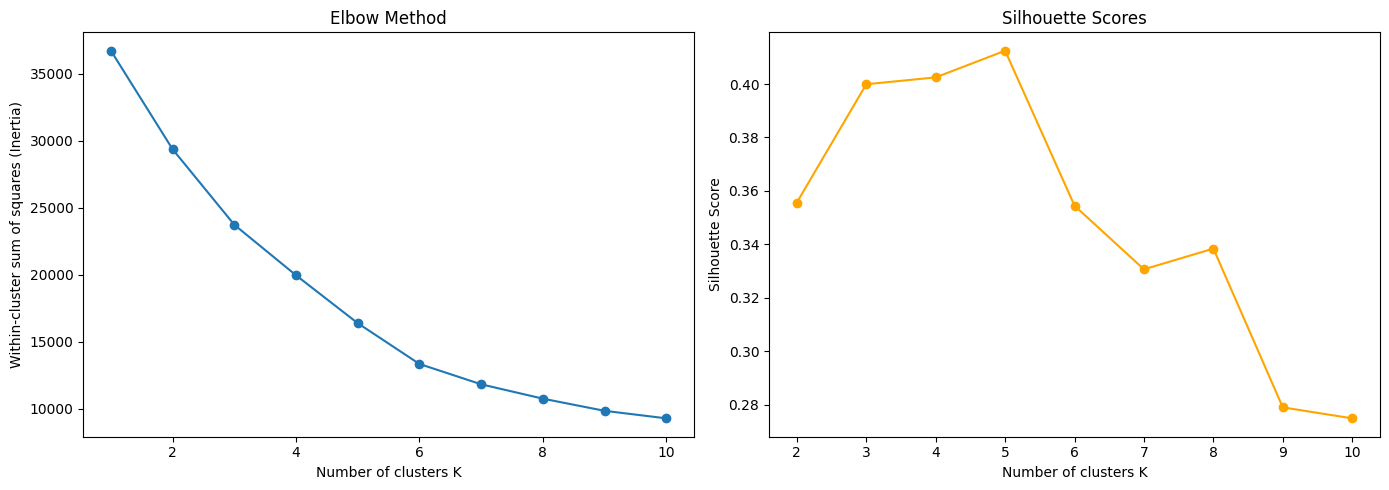

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_elbow), inertias, marker='o')
axes[0].set_xlabel("Number of clusters K")
axes[0].set_ylabel("Within-cluster sum of squares (Inertia)")
axes[0].set_title("Elbow Method")

axes[1].plot(list(K_silhouette), silhouette_scores, marker='o', color='orange')
axes[1].set_xlabel("Number of clusters K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Scores")

plt.tight_layout()
plt.show()

The elbow plot shows a gradual decrease with a subtle bend around K = 4–5, consistent with the silhouette peak at K = 5. We proceed with **K = 5** as the best-supported number of clusters.

Best K by silhouette score: 5


C:\Users\Jack\AppData\Local\Temp\ipykernel_62548\368779024.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', int(best_k))


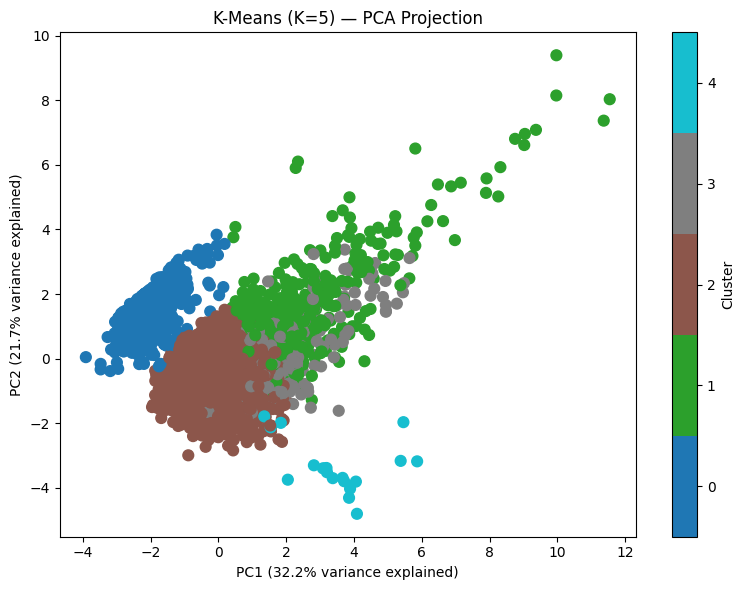

In [41]:
# Visualize the best K solution on the first two PCs
best_k = k_summary.loc[k_summary['Silhouette Score'].idxmax(), 'K']
print(f"Best K by silhouette score: {int(best_k)}")

km_best = KMeans(n_clusters=int(best_k), random_state=2, n_init=20)
cluster_labels = km_best.fit_predict(X_scaled)

pca_viz = PCA(n_components=2)
X_pca = pca_viz.fit_transform(X_scaled)

# Use a discrete colormap with exactly K colors
cmap = plt.cm.get_cmap('tab10', int(best_k))

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=cluster_labels,
                     cmap=cmap,
                     vmin=-0.5, vmax=int(best_k) - 0.5,
                     s=60)
ax.set_xlabel(f"PC1 ({pca_viz.explained_variance_ratio_[0]:.1%} variance explained)")
ax.set_ylabel(f"PC2 ({pca_viz.explained_variance_ratio_[1]:.1%} variance explained)")
ax.set_title(f"K-Means (K={int(best_k)}) — PCA Projection")
plt.colorbar(scatter, ax=ax, label='Cluster', ticks=range(int(best_k)))
plt.tight_layout()
plt.show()

 Cluster 0 is cleanly separated (supports the 0.414 silhouette). Clusters 1, 2, and 3 overlap in the center.The cluster 4 outliers at the bottom confirm the DNF filter didn't remove all early retirements, and they form a natural fifth cluster.

---
## Part 3 — Hierarchical Clustering

In [45]:
HClust = AgglomerativeClustering

hc_comp = HClust(distance_threshold=0, n_clusters=None, linkage='complete')
hc_comp.fit(X_scaled)

hc_ward = HClust(distance_threshold=0, n_clusters=None, linkage='ward')
hc_ward.fit(X_scaled)


AgglomerativeClustering(distance_threshold=0, n_clusters=None)

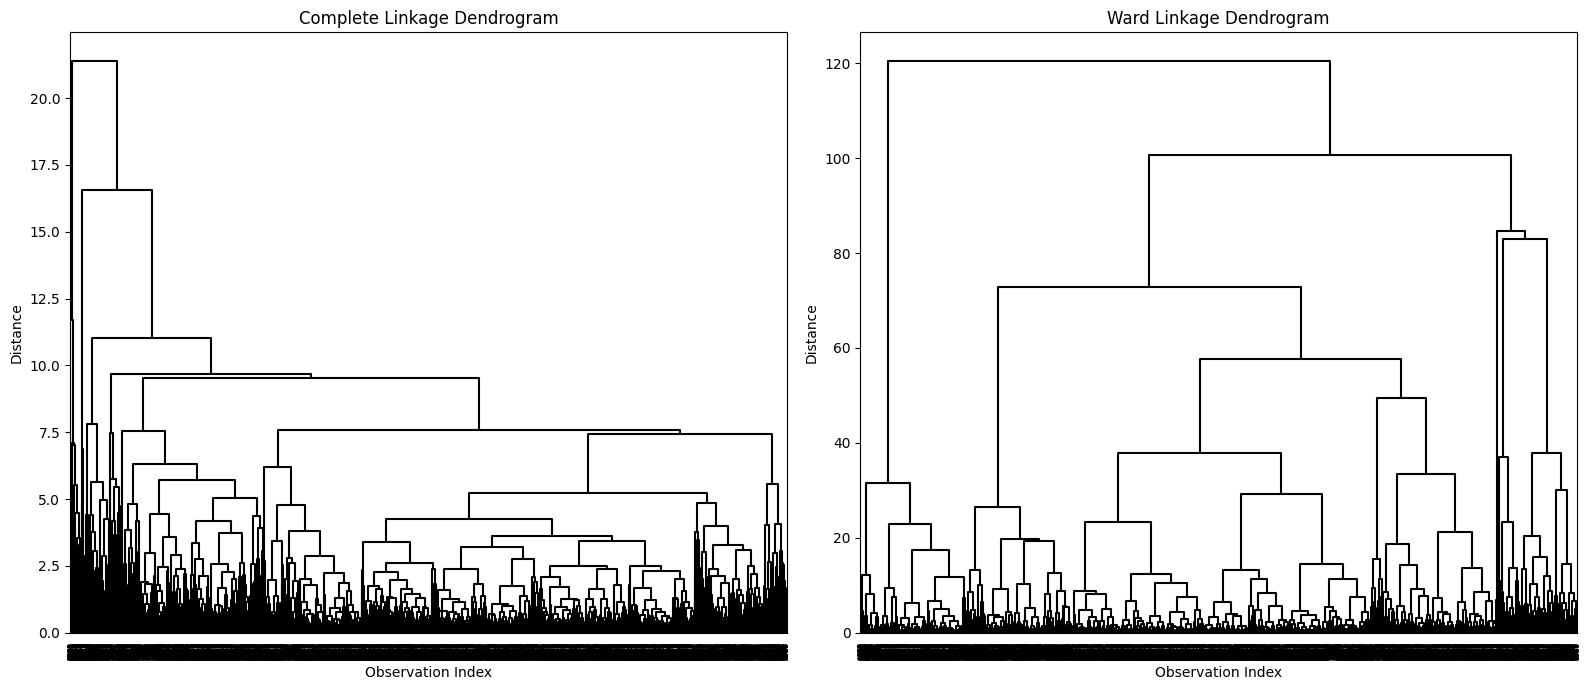

In [43]:
cargs = {'color_threshold': -np.inf, 'above_threshold_color': 'black'}

linkage_comp = compute_linkage(hc_comp)
linkage_ward = compute_linkage(hc_ward)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

dendrogram(linkage_comp, ax=axes[0], **cargs)
axes[0].set_title("Complete Linkage Dendrogram")
axes[0].set_xlabel("Observation Index")
axes[0].set_ylabel("Distance")

dendrogram(linkage_ward, ax=axes[1], **cargs)
axes[1].set_title("Ward Linkage Dendrogram")
axes[1].set_xlabel("Observation Index")
axes[1].set_ylabel("Distance")

plt.tight_layout()
plt.show()

Ward's dendrogram supports K=5 well. You can see a clear hierarchy with meaningful gaps at each split level. Complete linkage confirms the same outlier group exists (the early peel-off at the top) but isn't useful for finding the main structure. This is why Ward is the better choice here.

In [46]:
n_hclust = int(best_k)

comp_labels = cut_tree(linkage_comp, n_clusters=n_hclust).reshape(-1)
ward_labels = cut_tree(linkage_ward, n_clusters=n_hclust).reshape(-1)

print(f"Complete linkage — cluster sizes (K={n_hclust}):")
print(pd.Series(comp_labels).value_counts().sort_index())

print(f"\nWard linkage — cluster sizes (K={n_hclust}):")
print(pd.Series(ward_labels).value_counts().sort_index())

print("\nCross-tabulation: Complete Linkage vs K-Means")
display(pd.crosstab(pd.Series(comp_labels, name='HClust Complete'),
                    pd.Series(cluster_labels, name='K-Means')))

print("\nCross-tabulation: Ward Linkage vs K-Means")
pd.crosstab(pd.Series(ward_labels, name='HClust Ward'),
            pd.Series(cluster_labels, name='K-Means'))

Complete linkage — cluster sizes (K=5):
0    5627
1     209
2      90
3       9
4      19
Name: count, dtype: int64

Ward linkage — cluster sizes (K=5):
0     882
1    4401
2     473
3     180
4      18
Name: count, dtype: int64

Cross-tabulation: Complete Linkage vs K-Means


K-Means,0,1,2,3,4
HClust Complete,,,,,
0,894,365,4229,139,0
1,0,2,0,207,0
2,0,88,0,2,0
3,0,9,0,0,0
4,0,0,0,0,19



Cross-tabulation: Ward Linkage vs K-Means


K-Means,0,1,2,3,4
HClust Ward,,,,,
0,880,2,0,0,0
1,14,264,4120,2,1
2,0,18,109,346,0
3,0,180,0,0,0
4,0,0,0,0,18


- Clusters 0 and 4 are solid — both methods agree 99–100% on the front-runners and the DNF group. These arethe most real, well-separated clusters.
- The middle (clusters 1, 2, 3) disagrees at the margins — Ward merges K-Means clusters 1 and 2 into one large group, while K-Means splits them apart. This confirms the PCA plot observation: the midfield boundary is gradual, not sharp, so different methods draw the line slightly differently.
- Overall, strong cross-method agreement on the extremes (who clearly belongs at the top and bottom), with expected ambiguity in the dense center of the distribution.